In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("/content/insurance_data (1).csv")

print(df.head())

   age  bought_insurance
0   22                 0
1   25                 0
2   47                 1
3   52                 0
4   46                 1


In [5]:
X = df[['age']]
y = df['bought_insurance']

In [6]:
linear_model = LinearRegression()

linear_model.fit(X, y)

y_pred_linear = linear_model.predict(X)

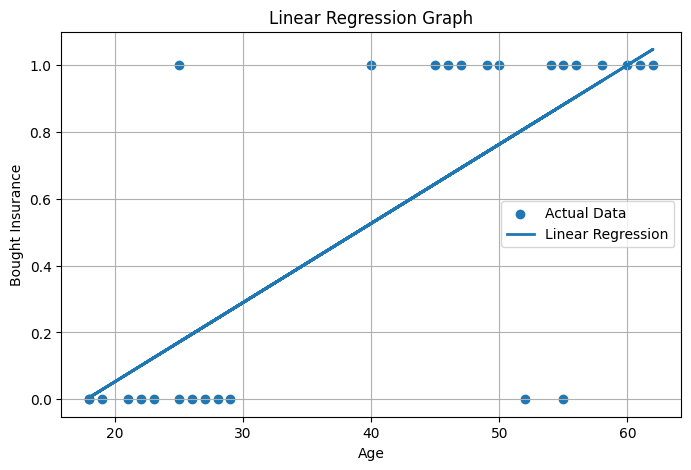

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, label='Actual Data')
plt.plot(X, y_pred_linear, linewidth=2, label='Linear Regression')

plt.title('Linear Regression Graph')
plt.xlabel('Age')
plt.ylabel('Bought Insurance')

plt.legend()
plt.grid(True)

plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [11]:
y_pred = logistic_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8571428571428571


In [12]:
age_range = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

age_range_scaled = scaler.transform(age_range)

y_prob = logistic_model.predict_proba(age_range_scaled)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


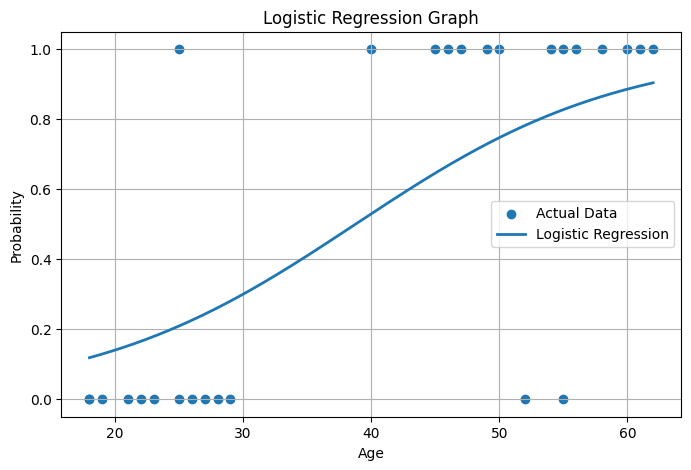

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, label='Actual Data')
plt.plot(age_range, y_prob, linewidth=2, label='Logistic Regression')

plt.title('Logistic Regression Graph')
plt.xlabel('Age')
plt.ylabel('Probability')

plt.legend()
plt.grid(True)

plt.show()